In [98]:
import os
from pathlib import Path
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import importlib
import utils, utils2

importlib.reload(utils)
importlib.reload(utils2)
# print(dir(utils))


<module 'utils2' from '/mnt/wsl/dataStorage/home/dev/projects/mlforht/utils2.py'>

In [ ]:
##### Definiçãos de diretórios com arquivos CSV
# Diretório raiz onde os arquivos CSV estão localizados (sem filtragem)
dir_path = r"/mnt/c/Users/deinf.janaelson/Documents/Datasets/"

# Diretório onde os arquivos CSV extraídos estão localizados
# dir_extracted = r"/mnt/c/Users/deinf.janaelson/Documents/Datasets/Extracted"
dir_extracted = r"./data"

In [94]:
Path(dir_extracted).mkdir(parents=True, exist_ok=True)
utils2.init_process_files(dir_path)

  0%|          | 0/40 [00:00<?, ?it/s]INFO:root:DataFrame processado: 19 linhas filtradas.
INFO:root:DataFrame processado: 3 linhas filtradas.
INFO:root:DataFrame processado: 18 linhas filtradas.
INFO:root:DataFrame processado: 12 linhas filtradas.
INFO:root:DataFrame processado: 11 linhas filtradas.
INFO:root:DataFrame processado: 11 linhas filtradas.
INFO:root:DataFrame processado: 15 linhas filtradas.
INFO:root:DataFrame processado: 8 linhas filtradas.
INFO:root:DataFrame processado: 13 linhas filtradas.
  5%|▌         | 2/40 [00:08<02:09,  3.41s/it]INFO:root:DataFrame processado: 10 linhas filtradas.
INFO:root:DataFrame processado: 10 linhas filtradas.
INFO:root:DataFrame processado: 10 linhas filtradas.
INFO:root:DataFrame processado: 8 linhas filtradas.
INFO:root:DataFrame processado: 6 linhas filtradas.
INFO:root:DataFrame processado: 10 linhas filtradas.
INFO:root:DataFrame processado: 10 linhas filtradas.
INFO:root:DataFrame processado: 9 linhas filtradas.
INFO:root:DataFrame 

,hash,data_de_cadastro,canal_de_atendimento,denuncia_emergencial,denunciante,cenario_da_violacao,pais,uf,municipio,frequencia,...,grau_de_instrucao_do_suspeito,religiao_do_suspeito,raca_cor_do_suspeito,suspeito_etnia,faixa_de_renda_do_suspeito,vinculo_orgao_pj_do_suspeito,sl_suspeito_ramo,suspeito_especificacao_etnia,vitima_especificacao_etnia,violacao
0,6fa1ed73ec4c3f385683c9fc03a3c062,12/01/2021 07:34,TELEFÔNICO,NÃO,ANÔNIMO,CASA DA VÍTIMA,BRASIL,SP,SÃO PAULO,DIARIAMENTE,...,N/D,N/D,PRETA,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
1,79c48e0d422d3ab1a306f8d7e498b8be,08/01/2021 23:11,TELEFÔNICO,NÃO,ANÔNIMO,SERVIÇO DE ABRIGAMENTO,BRASIL,SP,SÃO BERNARDO DO CAMPO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
2,ba12fedf0ff1a3bbe12b853e0ae2da65,13/01/2021 02:28,TELEFÔNICO,NÃO,ANÔNIMO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BRASIL,SP,SÃO PAULO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
3,3feb5ed25d579fa7b6d499d5781e59ff,13/01/2021 15:52,TELEFÔNICO,NÃO,ANÔNIMO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BRASIL,SP,SÃO PAULO,SEMANALMENTE,...,N/D,N/D,PRETA,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
4,1b13f107009820e1bc2f357e81b77d58,05/01/2021 08:28,CARTA,N/D,TERCEIRO,VIA PÚBLICA,BRASIL,RJ,RIO DE JANEIRO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6687,2B0FBA4434BC4A92AB23B2A9AB54CD8D034F686155CB19...,2025-12-22 10:45:06.237,TELEFÔNICO,NÃO,TERCEIRO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BR | BRASIL,PR,4106902 | CURITIBA,ÚNICA OCORRÊNCIA,...,NaN,NaN,PARDA,NaN,NaN,NaN,NaN,NaN,NaN,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE CRIA...
6688,F547BD2E9D51CBDAE85B1598E7ED86A2C0A84E6A9152F8...,2025-12-22 10:45:06.237,TELEFÔNICO,NÃO,TERCEIRO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BR | BRASIL,PR,4106902 | CURITIBA,ÚNICA OCORRÊNCIA,...,NaN,NaN,BRANCA,NaN,NaN,NaN,NaN,NaN,NaN,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE CRIA...
6689,F46BB5312B445A49BC6B163E1E7B7DC39C23FA198EBC94...,2025-12-22 10:45:06.237,TELEFÔNICO,NÃO,TERCEIRO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BR | BRASIL,PR,4106902 | CURITIBA,ÚNICA OCORRÊNCIA,...,NaN,NaN,BRANCA,NaN,NaN,NaN,NaN,NaN,NaN,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE CRIA...
6690,F4860AB6BDB19189CFBDDD135390F5B13A54B501F96C04...,2025-12-28 14:53:31.487,TELEFÔNICO,NÃO,TERCEIRO,LOCAL DE TRABALHO DA VÍTIMA,BR | BRASIL,SP,3547304 | SANTANA DE PARNAÍBA,DIARIAMENTE,...,NaN,NaN,PRETA,NaN,NaN,NaN,NaN,NaN,NaN,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE MULH...


In [27]:
def get_csv_files(dir):
    return [f for f in os.listdir(dir) if f.lower().endswith(".csv")]

In [ ]:
def load_dataset(csv_file, sep=";", encoding="utf-8") -> pd.DataFrame:
    return pd.read_csv(csv_file, sep=sep, encoding=encoding, low_memory=True)

In [28]:
files = get_csv_files(dir_extracted)

In [30]:
files

['disque100-2024-2.csv',
 'disque100-2025-2.csv',
 'disque100-2023-2.csv',
 'disque100-2022-2.csv',
 'disque100-2021-2.csv',
 'disque100-2022-1.csv',
 'disque100-2021-1.csv',
 'disque100-2025-1.csv',
 'disque100-2023-1.csv',
 'disque100-2024-1.csv']

In [60]:
del df_final   

In [61]:
files = get_csv_files(dir_extracted)
dfs = []
for f in files:
    path = os.path.join(dir_extracted, f)    
    df = load_dataset(path)
    dfs.append(df)  
    print(f"Carregado '{f}': {df.shape}")
df_final = pd.concat(dfs, ignore_index=True)
del dfs

Carregado 'disque100-2024-2.csv': (214, 62)
Carregado 'disque100-2025-2.csv': (443, 62)
Carregado 'disque100-2023-2.csv': (180, 62)
Carregado 'disque100-2022-2.csv': (89, 62)
Carregado 'disque100-2021-2.csv': (48, 62)
Carregado 'disque100-2022-1.csv': (73, 62)
Carregado 'disque100-2021-1.csv': (70, 62)
Carregado 'disque100-2025-1.csv': (291, 62)
Carregado 'disque100-2023-1.csv': (173, 62)
Carregado 'disque100-2024-1.csv': (167, 62)


In [62]:
df_final.shape

(1748, 62)

In [63]:
df_final.to_csv(os.path.join(dir_extracted, "dataset_trafico.csv"), index=False, sep=";", encoding="utf-8")

In [96]:
import os
import re
import unicodedata
import pandas as pd
import logging
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)

def normalize_columns(columns):
    def normalize(col):
        col = str(col).strip()
        col = unicodedata.normalize("NFKD", col)
        col = "".join(c for c in col if not unicodedata.combining(c))
        col = re.sub(r"[()\?\\/\-]", "_", col)
        col = re.sub(r"\s+", "_", col)
        col = re.sub(r"_+", "_", col)
        col = re.sub(r"[^a-zA-Z0-9]+$", "", col)
        return col.lower()

    return [normalize(c) for c in columns]

def rename_columns(columns):
    novas = []

    for col in columns:
        c = str(col).strip().lower()

        if c == "(nenhum nome de coluna)":
            novas.append("grupo_vulneravel")
        elif c == "sexo_do_suspeito":
            novas.append("genero_do_suspeito")
        elif c in ["sexo_da_vitima", "sexo_da_vítima"]:
            novas.append("genero_da_vitima")
        else:
            novas.append(col)

    return novas

def process_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "violacao" not in df.columns:
        raise ValueError("Coluna 'violacao' não encontrada no DataFrame.")

    df["violacao"] = df["violacao"].astype(str)

    violation_filter = df["violacao"].str.contains(
        r"TRAFICO|TRÁFICO",
        case=False,
        na=False,
        regex=True
    )

    df_filtered = df.loc[violation_filter].copy()

    return df_filtered

def process_csv_in_chunks(file_path: str, chunksize: int = 100000) -> pd.DataFrame:
    resultados = []

    for chunk in pd.read_csv(
        file_path,
        sep=";",
        encoding="utf-8",
        chunksize=chunksize,
        dtype=str
    ):
        df_filtered = process_dataframe(chunk)

        if not df_filtered.empty:
            resultados.append(df_filtered)
        
        del df_filtered
        del chunk

    return resultados

def orchestrate_processing(root_dir, max_workers=2):
    files = get_csv_files(root_dir)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        resultados = list(
            tqdm(executor.map(process_csv_in_chunks, files), total=len(files))
        )

    resultados = [df for df in resultados if not df.empty]

    if resultados:
        return pd.concat(resultados, ignore_index=True)

    return pd.DataFrame()

def get_csv_files(root_dir):
    csv_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.lower().endswith(".csv"):
                csv_files.append(os.path.join(dirpath, f))
    return csv_files

def init_process_files(root_dir, max_workers=2):
    files = get_csv_files(root_dir)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        resultados = list(
            tqdm(executor.map(process_csv_in_chunks, files), total=len(files))
        )

    resultados = [df for df in resultados if not df.empty]

    if resultados:
        return pd.concat(resultados, ignore_index=True)

    return pd.DataFrame()

In [83]:
del df_final

NameError: name 'df_final' is not defined

In [97]:
df_final = orchestrate_processing("/mnt/c/Users/deinf.janaelson/Documents/Datasets/")

100%|██████████| 40/40 [02:19<00:00,  3.50s/it]


AttributeError: 'list' object has no attribute 'empty'

In [89]:
df_final.shape

(6692, 63)

<Axes: >

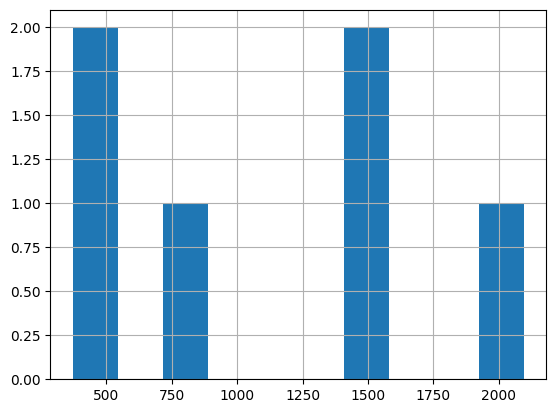

In [88]:
df_final.get("violacao").value_counts().hist()

In [77]:
df_final.shape[0] - df_final.duplicated().sum()

np.int64(1673)